In [2]:
from genominterv.remapping import remap
from genominterv.remapping import interval_distance, genomic
from genominterv.remapping import remap_interval_data


In [3]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/home/johanulstrup/johan_gpn/people/johanulsrup/johan_gpn/data/human/autosome_hg38_compartments.csv")

# Check the first few rows to verify it loaded correctly
print(df.head())

# Filter for chromosome 8 and chromosome X
chr8_df = df[df["chrom"] == "chr8"].reset_index(drop=True)


# Optional: display the number of rows for each
print(f"chr8 rows: {len(chr8_df)}")


print(chr8_df.head())



  chrom   start     end  E1_X compart_X  E1_Y compart_Y
0  chr1       0   50000   NaN         B   NaN         B
1  chr1   50000  100000   NaN         B   NaN         B
2  chr1  100000  150000   NaN         B   NaN         B
3  chr1  150000  200000   NaN         B   NaN         B
4  chr1  200000  250000   NaN         B   NaN         B
chr8 rows: 2903
  chrom   start     end      E1_X compart_X     E1_Y compart_Y
0  chr8       0   50000       NaN         B      NaN         B
1  chr8   50000  100000       NaN         B      NaN         B
2  chr8  100000  150000       NaN         B      NaN         B
3  chr8  150000  200000       NaN         B      NaN         B
4  chr8  200000  250000 -0.084579         B -0.29916         B


In [4]:
import pandas as pd

# Load the CSV file
chrx_df = pd.read_csv("/home/johanulstrup/johan_gpn/people/johanulsrup/johan_gpn/data/human/chrX_hg38_compartments.csv")

# Optional: display the number of rows for each
print(f"chr8 rows: {len(chr8_df)}")


print(chrx_df.head())

chr8 rows: 2903
  chrom   start     end  E1 compart
0  chrX       0   50000 NaN       B
1  chrX   50000  100000 NaN       B
2  chrX  100000  150000 NaN       B
3  chrX  150000  200000 NaN       B
4  chrX  200000  250000 NaN       B


In [5]:
import pandas as pd

# assuming chr8_df is already loaded

# select the needed columns and rename
df_chr8 = chr8_df[["compart_X", "start", "end", "chrom"]].rename(
    columns={"compart_X": "comp"}
)[["chrom", "start", "end", "comp"]]
print("chr8 data:")
print(df_chr8.head())
print(df_chr8.shape)

# select the needed columns and rename
df_chrx = chrx_df[["compart", "start", "end", "chrom"]].rename(
    columns={"compart": "comp"}
)[["chrom", "start", "end", "comp"]]
print("chrX data:")
print(df_chrx.head())
print(df_chrx.shape)


chr8 data:
  chrom   start     end comp
0  chr8       0   50000    B
1  chr8   50000  100000    B
2  chr8  100000  150000    B
3  chr8  150000  200000    B
4  chr8  200000  250000    B
(2903, 4)
chrX data:
  chrom   start     end comp
0  chrX       0   50000    B
1  chrX   50000  100000    B
2  chrX  100000  150000    B
3  chrX  150000  200000    B
4  chrX  200000  250000    B
(3121, 4)


In [6]:
import pandas as pd

def create_A_B_compartments(df):
    """
    Merge consecutive A/B compartments into continuous intervals.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: ["comp", "start", "end", "chrom"]

    Returns
    -------
    merged_df : pd.DataFrame
        DataFrame with merged intervals: ["comp", "start", "end", "chrom"]
    """
    # Ensure proper sorting
    df = df.sort_values(by=["chrom", "start"]).reset_index(drop=True)
    
    merged = []
    current_comp = df.loc[0, "comp"]
    current_start = df.loc[0, "start"]
    current_chrom = df.loc[0, "chrom"]

    for i in range(1, len(df)):
        row = df.loc[i]
        if row["comp"] != current_comp or row["chrom"] != current_chrom:
            # Close previous interval
            #merged.append([current_comp, current_start, df.loc[i-1, "end"], current_chrom])
            merged.append([current_chrom, current_start, df.loc[i-1, "end"], current_comp])
            # Start new one
            current_comp = row["comp"]
            current_start = row["start"]
            current_chrom = row["chrom"]

    # # Add last interval
    # merged.append([current_comp, current_start, df.loc[len(df)-1, "end"], current_chrom])

    # return pd.DataFrame(merged, columns=["comp", "start", "end", "chrom"])
    # Add last interval
    merged.append([current_chrom, current_start, df.loc[len(df)-1, "end"], current_comp])

    return pd.DataFrame(merged, columns=["chrom", "start", "end", "comp"])


df_chrx_intervals = create_A_B_compartments(df_chrx)
df_chr8_intervals = create_A_B_compartments(df_chr8)

print(df_chrx_intervals.head())
print(df_chr8_intervals.head())


  chrom    start      end comp
0  chrX        0  2800000    B
1  chrX  2800000  3800000    A
2  chrX  3800000  3950000    B
3  chrX  3950000  4550000    A
4  chrX  4550000  4600000    B
  chrom    start       end comp
0  chr8        0   1750000    B
1  chr8  1750000   1800000    A
2  chr8  1800000   9750000    B
3  chr8  9750000   9800000    A
4  chr8  9800000  10300000    B


In [7]:
import pandas as pd

# Path to the BEDGraph file
recomb_file = "/home/johanulstrup/johan_gpn/people/johanulsrup/johan_gpn/data/human/recombMat.bedGraph"

# Load the BEDGraph file (tab-delimited, no header by default)
recomb_df = pd.read_csv(recomb_file, sep="\t", header=None, names=["chrom", "start", "end", "value"])

#recomb_df = recomb_df[["chrom","start", "end"]]
# Separate data for chr8
chr8_recomb = recomb_df[recomb_df["chrom"] == "chr8"].reset_index(drop=True)

# Separate data for chrX
chrx_recomb = recomb_df[recomb_df["chrom"] == "chrX"].reset_index(drop=True)

# Optional: Check the number of entries
print(f"chr8 rows: {len(chr8_recomb)}")
print(chr8_recomb.head())
print(f"chrX rows: {len(chrx_recomb)}")
print(chrx_recomb.head())



chr8 rows: 56890
  chrom   start     end         value
0  chr8  727305  757884  0.000000e+00
1  chr8  757884  763377  1.160240e-25
2  chr8  763377  764383  2.221080e-24
3  chr8  764383  766867  2.069560e-15
4  chr8  766867  769043  4.911460e-09
chrX rows: 23976
  chrom    start      end         value
0  chrX  3532526  3533229  2.641420e-01
1  chrX  3533229  3534231  1.352180e+00
2  chrX  3534231  3580516  0.000000e+00
3  chrX  3580516  3582267  6.668370e-14
4  chrX  3582267  3582957  9.080830e-11


In [8]:
import pandas as pd

def clean_and_sort(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean a genomic interval DataFrame:
      - Drop rows with missing start/end
      - Convert start/end to integers
      - Sort by chrom, start, end
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    
    required_cols = {"chrom", "start", "end"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns {required_cols}")

    df_clean = df.dropna(subset=["start", "end"]).copy()
    df_clean["start"] = df_clean["start"].astype(int)
    df_clean["end"] = df_clean["end"].astype(int)
    df_clean = df_clean.sort_values(by=["chrom", "start", "end"]).reset_index(drop=True)
    
    # Force return as DataFrame
    return pd.DataFrame(df_clean)

# Apply to recombination data
chrx_recomb_clean = clean_and_sort(chrx_recomb)
chr8_recomb_clean = clean_and_sort(chr8_recomb)

# Apply to compartment anchor data
df_chrx_clean = clean_and_sort(df_chrx_intervals)
df_chr8_clean = clean_and_sort(df_chr8_intervals)

# Quick peek
print("chrX recomb (chrx_recomb_clean):\n", chrx_recomb_clean.head(), "\n")
print("chrX compartments (df_chrx_clean):\n", df_chrx_clean.head(), "\n")

# Check types explicitly
print(type(chrx_recomb_clean))
print(type(df_chrx_clean))


chrX recomb (chrx_recomb_clean):
   chrom    start      end         value
0  chrX  3532526  3533229  2.641420e-01
1  chrX  3533229  3534231  1.352180e+00
2  chrX  3534231  3580516  0.000000e+00
3  chrX  3580516  3582267  6.668370e-14
4  chrX  3582267  3582957  9.080830e-11 

chrX compartments (df_chrx_clean):
   chrom    start      end comp
0  chrX        0  2800000    B
1  chrX  2800000  3800000    A
2  chrX  3800000  3950000    B
3  chrX  3950000  4550000    A
4  chrX  4550000  4600000    B 

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [9]:
import numpy as np
import pandas as pd
from genominterv.remapping import remap_interval_data
print(chrx_recomb_clean.head())
print(df_chrx_clean.head())
# Remap chrX compartments relative to recombination intervals
remapped_chrx = remap_interval_data(chrx_recomb_clean, df_chrx_clean, include_prox_coord=True)
#remapped_chrx_int = remap_interval_data( df_chrx_clean, chrx_recomb_clean, include_prox_coord=True)
print("Remapped chrX data:")
print(remapped_chrx.shape)
print(remapped_chrx.head())
# print("Remapped invertchrX data:")
# print(remapped_chrx_int.shape)
# print(remapped_chrx_int.head())

  chrom    start      end         value
0  chrX  3532526  3533229  2.641420e-01
1  chrX  3533229  3534231  1.352180e+00
2  chrX  3534231  3580516  0.000000e+00
3  chrX  3580516  3582267  6.668370e-14
4  chrX  3582267  3582957  9.080830e-11
  chrom    start      end comp
0  chrX        0  2800000    B
1  chrX  2800000  3800000    A
2  chrX  3800000  3950000    B
3  chrX  3950000  4550000    A
4  chrX  4550000  4600000    B


Remapped chrX data:
(47952, 8)
   start  end  start_prox  end_prox chrom  start_orig  end_orig     value
0    NaN  NaN         NaN       NaN  chrX     3532526   3533229  0.264142
1    NaN  NaN         NaN       NaN  chrX     3532526   3533229  0.264142
2    NaN  NaN         NaN       NaN  chrX     3533229   3534231  1.352180
3    NaN  NaN         NaN       NaN  chrX     3533229   3534231  1.352180
4    NaN  NaN         NaN       NaN  chrX     3534231   3580516  0.000000


In [10]:
# Remap chr8 compartments relative to recombination intervals
remapped_chr8 = remap_interval_data(chr8_recomb, df_chr8, include_prox_coord=True)
print("Remapped chr8 data:")
print(remapped_chr8.shape)

remapped_chr8.head()


Remapped chr8 data:
(113780, 8)


,start,end,start_prox,end_prox,chrom,start_orig,end_orig,value
0,NaN,NaN,NaN,NaN,chr8,727305,757884,0.000000e+00
1,NaN,NaN,NaN,NaN,chr8,727305,757884,0.000000e+00
2,NaN,NaN,NaN,NaN,chr8,757884,763377,1.160240e-25
3,NaN,NaN,NaN,NaN,chr8,757884,763377,1.160240e-25
4,NaN,NaN,NaN,NaN,chr8,763377,764383,2.221080e-24


In [11]:
import pandas as pd
import numpy as np
from genominterv.remapping import remap_interval_data

def clean_and_prepare_data(df, coordinate_cols=['start', 'end']):
    """
    Clean and prepare dataframe for remapping by handling NaN values and data types.
    
    Parameters:
    df: Input DataFrame
    coordinate_cols: List of coordinate columns to clean
    
    Returns:
    cleaned_df: Cleaned DataFrame
    """
    print(f"Cleaning data. Initial shape: {df.shape}")
    
    # Create a copy to avoid modifying original
    cleaned_df = df.copy()
    
    # Drop rows with NaN in coordinate columns
    cleaned_df = cleaned_df.dropna(subset=coordinate_cols).copy()
    
    # Convert coordinates to integers
    for col in coordinate_cols:
        cleaned_df[col] = cleaned_df[col].astype(int)
    
    # Sort by genomic coordinates
    if 'chrom' in cleaned_df.columns:
        cleaned_df = cleaned_df.sort_values(by=['chrom'] + coordinate_cols)
    else:
        cleaned_df = cleaned_df.sort_values(by=coordinate_cols)
    
    print(f"Data cleaned. Final shape: {cleaned_df.shape}")
    return cleaned_df

def perform_genomic_remapping(query_data, target_intervals, include_prox_coord=True):
    """
    Perform genomic interval remapping using genominterv library.
    
    Parameters:
    query_data: DataFrame with data to be remapped (e.g., GC content, recombination rates)
                Must have columns: chrom, start, end, value
    target_intervals: DataFrame with target intervals (e.g., compartment edges)  
                     Must have columns: chrom, start, end, comp (and other metadata)
    include_prox_coord: Whether to include proximity coordinates in output
    
    Returns:
    result_df: DataFrame with remapped data
    """
    print("Starting genomic remapping...")
    print(f"Query data shape: {query_data.shape}")
    print(f"Target intervals shape: {target_intervals.shape}")
    
    # Clean both datasets
    query_clean = clean_and_prepare_data(query_data)
    target_clean = clean_and_prepare_data(target_intervals)
    
    try:
        # Perform the remapping
        # Note: The order matters - query_data is what gets remapped TO the target_intervals
        result = remap_interval_data(
            query_clean, 
            target_clean, 
            include_prox_coord=include_prox_coord
        )
        
        # Post-process the results
        result = post_process_remapping_result(result)
        
        print(f"Remapping completed successfully. Result shape: {result.shape}")
        return result
        
    except Exception as e:
        print(f"Error during remapping: {str(e)}")
        raise

def post_process_remapping_result(result):
    """
    Post-process remapping results to add useful columns and clean data.
    
    Parameters:
    result: Raw result from remap_interval_data
    
    Returns:
    processed_result: Processed DataFrame
    """
    print("Post-processing remapping results...")
    
    # Calculate midpoint and absolute midpoint
    result["mid"] = (result["start"] + result["end"]) / 2
    result["absmid"] = result["mid"].abs()
    
    # Drop rows with NaN values in critical columns
    critical_cols = ["start", "end", "mid", "absmid"]
    
    # Add proximity coordinates if they exist
    if "start_prox" in result.columns and "end_prox" in result.columns:
        critical_cols.extend(["start_prox", "end_prox"])
    
    initial_shape = result.shape
    result = result.dropna(subset=critical_cols, how="any")
    final_shape = result.shape
    
    print(f"Dropped NaN rows: {initial_shape} -> {final_shape}")
    
    return result

def remap_and_save(query_data, target_intervals, output_path=None, 
                   include_prox_coord=True, save_format="tsv"):
    """
    Complete pipeline to remap data and optionally save results.
    
    Parameters:
    query_data: DataFrame with data to be remapped
    target_intervals: DataFrame with target intervals
    output_path: Path to save the results (optional)
    include_prox_coord: Whether to include proximity coordinates
    save_format: Format to save ("tsv" or "csv")
    
    Returns:
    result_df: The remapped DataFrame
    """
    # Perform remapping
    result = perform_genomic_remapping(
        query_data=query_data,
        target_intervals=target_intervals,
        include_prox_coord=include_prox_coord
    )
    
    # Save results if path provided
    if output_path:
        if save_format.lower() == "tsv":
            result.to_csv(output_path, sep="\t", index=False)
            print(f"Results saved as TSV to: {output_path}")
        else:
            result.to_csv(output_path, index=False)
            print(f"Results saved as CSV to: {output_path}")
    
    # Print preview
    print("Result preview:")
    print(f"Shape: {result.shape}")
    print(f"Columns: {list(result.columns)}")
    print("\nFirst few rows:")
    print(result.head())
    
    if "start_prox" in result.columns:
        print(f"Unique proximity starts: {sorted(result['start_prox'].unique())}")
    
    return result

def create_compartment_edges_from_segments(compartments_df, edge_window=1):
    """
    Create compartment edge intervals from compartment segment data.
    
    Parameters:
    compartments_df: DataFrame with compartment segments (chrom, start, end, comp)
    edge_window: Size of window around each edge (default 1 bp)
    
    Returns:
    edges_df: DataFrame with edge intervals and compartment assignments
    """
    print("Creating compartment edges from segment data...")
    print(f"Input segments shape: {compartments_df.shape}")
    
    edges_list = []
    
    # Sort compartments by position
    comp_sorted = compartments_df.sort_values(['chrom', 'start']).reset_index(drop=True)
    
    # Create edges between adjacent compartments
    for i in range(len(comp_sorted) - 1):
        current_seg = comp_sorted.iloc[i]
        next_seg = comp_sorted.iloc[i + 1]
        
        # Check if segments are adjacent
        if current_seg['end'] == next_seg['start']:
            edge_pos = current_seg['end']  # = next_seg['start']
            
            # Create edge interval
            edge_entry = {
                'chrom': current_seg['chrom'],
                'start': edge_pos - edge_window // 2,
                'end': edge_pos + edge_window // 2,
                'edge_pos': edge_pos,
                'left_comp': current_seg['comp'],
                'right_comp': next_seg['comp'],
                'comp': current_seg['comp']  # Use left compartment as primary
            }
            edges_list.append(edge_entry)
    
    edges_df = pd.DataFrame(edges_list)
    print(f"Created {len(edges_df)} compartment edges")
    
    return edges_df

# Simple usage functions for Jupyter notebooks
def remap_recombination_to_compartments(chrx_recomb_clean, df_chrx_clean):
    """
    Simple function to remap recombination data to compartment edges.
    Assumes your DataFrames are already loaded in the notebook.
    
    Parameters:
    chrx_recomb_clean: Your recombination DataFrame
    df_chrx_clean: Your compartment segments DataFrame
    
    Returns:
    remapped_df: Remapped recombination data
    """
    print("=== Remapping Recombination Data to Compartment Edges ===")
    print(f"Recombination data shape: {chrx_recomb_clean.shape}")
    print(f"Compartment data shape: {df_chrx_clean.shape}")
    
    # Step 1: Create compartment edges
    compartment_edges = create_compartment_edges_from_segments(df_chrx_clean)
    print("\nCompartment edges preview:")
    print(compartment_edges)
    
    # Step 2: Perform remapping
    result = perform_genomic_remapping(
        query_data=chrx_recomb_clean,
        target_intervals=compartment_edges,
        include_prox_coord=True
    )
    
    print("\n=== REMAPPING COMPLETE ===")
    print(f"Final remapped data shape: {result.shape}")
    
    return result

# Even simpler one-liner function
def quick_remap(chrx_recomb_clean, df_chrx_clean, save_path=None):
    """
    One-line function to remap and optionally save.
    """
    edges = create_compartment_edges_from_segments(df_chrx_clean)
    return remap_and_save(chrx_recomb_clean, edges, save_path)

In [12]:
# Just remap (no saving)
result_chrx = quick_remap(chrx_recomb, df_chrx_clean)

# Remap and save
result_chrx = quick_remap(chrx_recomb, df_chrx_clean, "my_remapped_data.tsv")

# Just remap (no saving)
result_chr8 = quick_remap(chr8_recomb, df_chr8_clean)

# Remap and save
result_chr8 = quick_remap(chr8_recomb, df_chr8_clean, "my_remapped_data.tsv")


Creating compartment edges from segment data...
Input segments shape: (323, 4)
Created 322 compartment edges
Starting genomic remapping...
Query data shape: (23976, 4)
Target intervals shape: (322, 7)
Cleaning data. Initial shape: (23976, 4)
Data cleaned. Final shape: (23976, 4)
Cleaning data. Initial shape: (322, 7)
Data cleaned. Final shape: (322, 7)
Post-processing remapping results...
Dropped NaN rows: (23941, 10) -> (23941, 10)
Remapping completed successfully. Result shape: (23941, 10)
Result preview:
Shape: (23941, 10)
Columns: ['start', 'end', 'start_prox', 'end_prox', 'chrom', 'start_orig', 'end_orig', 'value', 'mid', 'absmid']

First few rows:
    start       end  start_prox  end_prox chrom  start_orig  end_orig  \
0 -266771 -267474.0     3800000   3800000  chrX     3532526   3533229   
1 -265769 -266771.0     3800000   3800000  chrX     3533229   3534231   
2 -219484 -265769.0     3800000   3800000  chrX     3534231   3580516   
3 -217733 -219484.0     3800000   3800000  chr

In [13]:
def add_compartment_info(result, df_chrx_clean):
    """
    Add compartment information to remapped data by matching start_prox to compartment starts.
    
    Parameters:
    result: DataFrame from quick_remap() with start_prox column
    df_chrx_clean: Compartment segments DataFrame (chrom, start, end, comp)
    
    Returns:
    result_with_comp: DataFrame with added 'comp' column
    """
    # Create a copy to avoid modifying original
    result_with_comp = result.copy()
    
    if 'start_prox' in result.columns:
        # Create a mapping from compartment start positions to comp values
        comp_mapping = dict(zip(df_chrx_clean['start'], df_chrx_clean['comp']))
        
        print("Compartment mapping:")
        for start_pos, comp in comp_mapping.items():
            print(f"  Start {start_pos:,} -> Compartment {comp}")
        
        # Map start_prox values to compartment types
        result_with_comp['comp'] = result['start_prox'].map(comp_mapping)
        
        print(f"\nAdded compartment info:")
        print(f"Unique compartments: {result_with_comp['comp'].value_counts().to_dict()}")
        
        # Show any unmapped values
        unmapped = result_with_comp[result_with_comp['comp'].isna()]
        if len(unmapped) > 0:
            print(f"Warning: {len(unmapped)} rows could not be mapped to compartments")
            print(f"Unmapped start_prox values: {unmapped['start_prox'].unique()}")
        
    else:
        print("Error: start_prox column not found in result")
        return result
    
    return result_with_comp

# Usage example:
# result = quick_remap(chrx_recomb_clean, df_chrx_clean)
# result_with_comp = add_compartment_info(result, df_chrx_clean)

In [14]:
result_with_comp_chrx = add_compartment_info(result_chrx, df_chrx_clean)

result_with_comp_chr8 = add_compartment_info(result_chr8, df_chr8_clean)



Compartment mapping:
  Start 0 -> Compartment B
  Start 2,800,000 -> Compartment A
  Start 3,800,000 -> Compartment B
  Start 3,950,000 -> Compartment A
  Start 4,550,000 -> Compartment B
  Start 4,600,000 -> Compartment A
  Start 5,600,000 -> Compartment B
  Start 5,650,000 -> Compartment A
  Start 8,450,000 -> Compartment B
  Start 8,500,000 -> Compartment A
  Start 18,900,000 -> Compartment B
  Start 18,950,000 -> Compartment A
  Start 20,150,000 -> Compartment B
  Start 20,300,000 -> Compartment A
  Start 20,350,000 -> Compartment B
  Start 20,950,000 -> Compartment A
  Start 21,000,000 -> Compartment B
  Start 21,100,000 -> Compartment A
  Start 21,200,000 -> Compartment B
  Start 21,250,000 -> Compartment A
  Start 21,300,000 -> Compartment B
  Start 21,350,000 -> Compartment A
  Start 21,400,000 -> Compartment B
  Start 21,500,000 -> Compartment A
  Start 21,700,000 -> Compartment B
  Start 21,850,000 -> Compartment A
  Start 21,950,000 -> Compartment B
  Start 22,450,000 -> Com

In [15]:
print(result_with_comp_chrx.head())
print(result_with_comp_chrx["comp"].unique())

    start       end  start_prox  end_prox chrom  start_orig  end_orig  \
0 -266771 -267474.0     3800000   3800000  chrX     3532526   3533229   
1 -265769 -266771.0     3800000   3800000  chrX     3533229   3534231   
2 -219484 -265769.0     3800000   3800000  chrX     3534231   3580516   
3 -217733 -219484.0     3800000   3800000  chrX     3580516   3582267   
4 -217043 -217733.0     3800000   3800000  chrX     3582267   3582957   

          value       mid    absmid comp  
0  2.641420e-01 -267122.5  267122.5    B  
1  1.352180e+00 -266270.0  266270.0    B  
2  0.000000e+00 -242626.5  242626.5    B  
3  6.668370e-14 -218608.5  218608.5    B  
4  9.080830e-11 -217388.0  217388.0    B  
['B' 'A']


In [16]:
def filter_into_A_B_compartments(result):
    """
    Splits the input DataFrame into A and B compartments based on sign of 'start' and compartment identity.
    
    Parameters:
        result (pd.DataFrame): Must include columns 'comp' and 'start'.
    
    Returns:
        A_val (pd.DataFrame): Entries where position is consistent with Compartment A.
        B_val (pd.DataFrame): Entries where position is consistent with Compartment B.
    """
    # Entries within A compartment (left of origin if A, right if B)
    A_val = result[
        ((result['comp'] == 'A') & (result['start'] > 0)) |     # is greater than 0
        ((result['comp'] == 'B') & (result['start'] < 0))       # is less than 0
    ].copy()

    # Entries within B compartment (right of origin if A, left if B)
    B_val = result[
        ((result['comp'] == 'A') & (result['start'] < 0)) |     # is less than 0
        ((result['comp'] == 'B') & (result['start'] > 0))       # is greater than 0
    ].copy()

    return A_val, B_val



In [17]:
result_with_comp_chrx_A, result_with_comp_chrx_B = filter_into_A_B_compartments(result_with_comp_chrx)
result_with_comp_chr8_A, result_with_comp_chr8_B = filter_into_A_B_compartments(result_with_comp_chr8)
print(result_with_comp_chrx_A.head())
print(result_with_comp_chrx_B.head())

    start       end  start_prox  end_prox chrom  start_orig  end_orig  \
0 -266771 -267474.0     3800000   3800000  chrX     3532526   3533229   
1 -265769 -266771.0     3800000   3800000  chrX     3533229   3534231   
2 -219484 -265769.0     3800000   3800000  chrX     3534231   3580516   
3 -217733 -219484.0     3800000   3800000  chrX     3580516   3582267   
4 -217043 -217733.0     3800000   3800000  chrX     3582267   3582957   

          value       mid    absmid comp  
0  2.641420e-01 -267122.5  267122.5    B  
1  1.352180e+00 -266270.0  266270.0    B  
2  0.000000e+00 -242626.5  242626.5    B  
3  6.668370e-14 -218608.5  218608.5    B  
4  9.080830e-11 -217388.0  217388.0    B  
     start     end  start_prox  end_prox chrom  start_orig  end_orig  \
116    265  1875.0     3800000   3800000  chrX     3800265   3801875   
117   1875  2225.0     3800000   3800000  chrX     3801875   3802225   
118   2225  2455.0     3800000   3800000  chrX     3802225   3802455   
119   2455  736

In [25]:
#print(result_with_comp_chr8_A.head())
print(result_with_comp_chr8_B.head())
average_value = result_with_comp_chr8_B["value"].mean()
print("Average of value column:", average_value)
first_20_values = result_with_comp_chr8_B["value"].head(20).tolist()
print(first_20_values)

     start     end  start_prox   end_prox chrom  start_orig  end_orig  \
656    775  1620.0   1800000.0  1800000.0  chr8     1800775   1801620   
657   1620  2553.0   1800000.0  1800000.0  chr8     1801620   1802553   
658   2553  2911.0   1800000.0  1800000.0  chr8     1802553   1802911   
659   2911  4937.0   1800000.0  1800000.0  chr8     1802911   1804937   
660   4937  6390.0   1800000.0  1800000.0  chr8     1804937   1806390   

        value     mid  absmid comp  bin  
656  0.007402  1197.5  1197.5    B  0.0  
657  0.045151  2086.5  2086.5    B  0.0  
658  0.145695  2732.0  2732.0    B  0.0  
659  0.402280  3924.0  3924.0    B  0.0  
660  6.854380  5663.5  5663.5    B  0.0  
Average of value column: 11.629439634100473
[0.00740151, 0.0451509, 0.145695, 0.40228, 6.85438, 18.2757, 0.0816802, 0.0232943, 0.471615, 1.17689, 14.801, 24.4948, 1.85155, 0.373369, 0.149044, 19.332, 0.149044, 0.0101789, 0.225909, 0.034528]


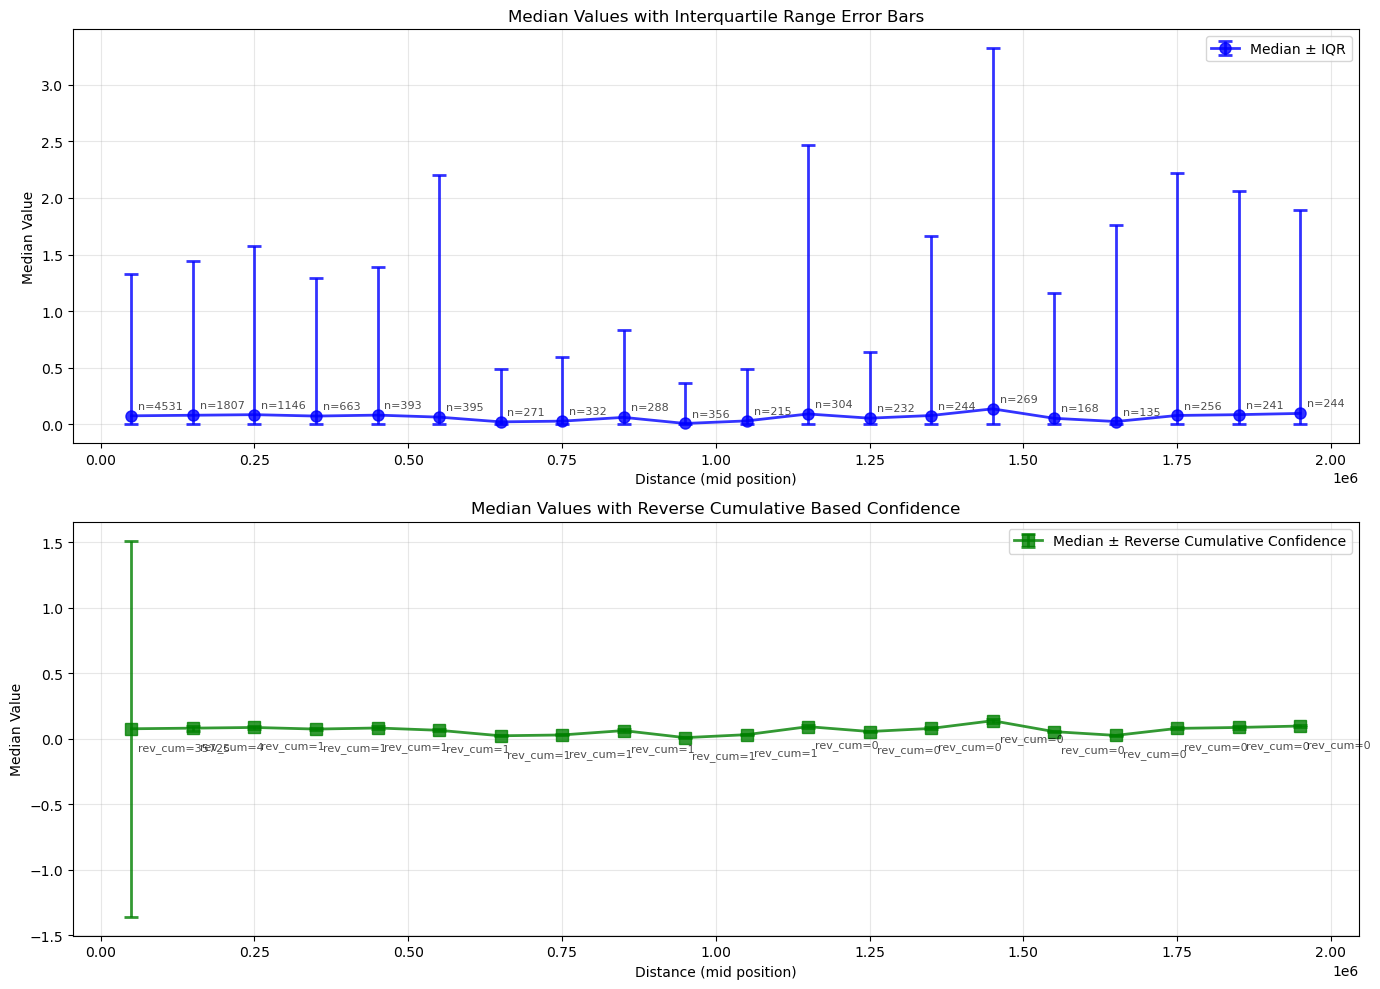

DETAILED BIN STATISTICS:
Bin Range                Count  Median     IQR             Rev_Cum 
--------------------------------------------------------------------------------
0   0-100000             4531   0.0760     1.3277          35725   
1   100000-200000        1807   0.0809     1.4466          4       
2   200000-300000        1146   0.0862     1.5787          1       
3   300000-400000        663    0.0737     1.2948          1       
4   400000-500000        393    0.0821     1.3928          1       
5   500000-600000        395    0.0644     2.2057          1       
6   600000-700000        271    0.0225     0.4853          1       
7   700000-800000        332    0.0289     0.5981          1       
8   800000-900000        288    0.0621     0.8302          1       
9   900000-1000000       356    0.0084     0.3671          1       
10  1000000-1100000      215    0.0310     0.4856          1       
11  1100000-1200000      304    0.0922     2.4691          0       
12  120000

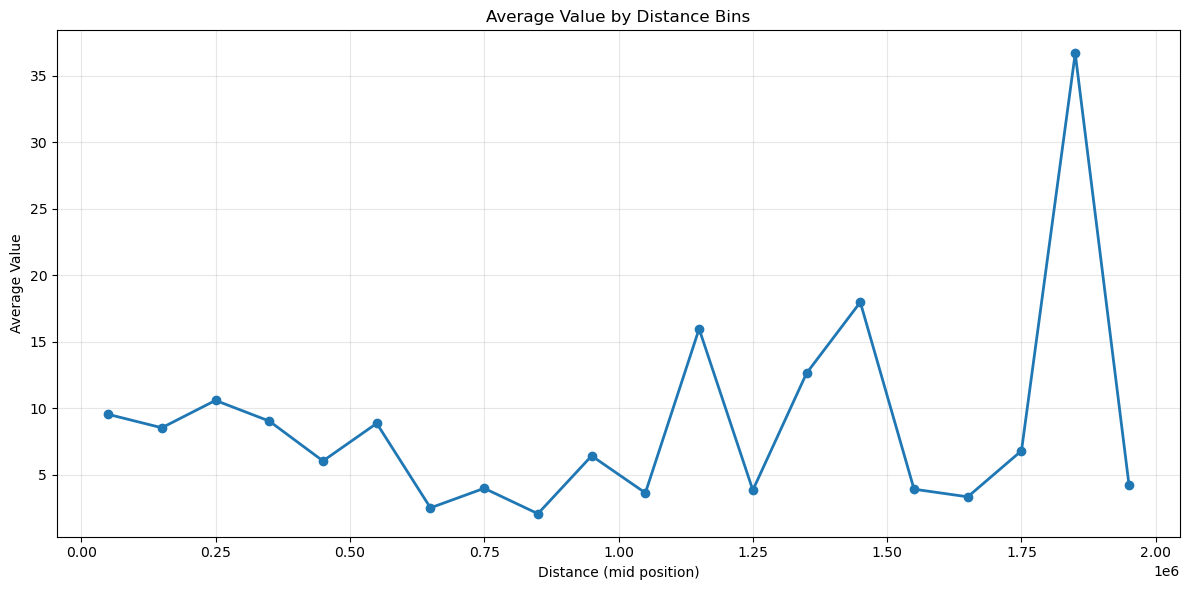


Summary:
Total rows: 35925
Mid range: -9324153.0 - 9323937.0
Value range: 0.000000 - 12149.200000


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming your dataframe is named result_with_comp_chr8_B
# If you need to load it, uncomment and modify the line below:
# result_with_comp_chr8_B = pd.read_csv('your_file.csv')

# Parameters
max_dist = 2_000_000
bins = 20

# Create bin edges
bin_edges = np.linspace(0, max_dist, bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Assign each row to a bin based on the 'mid' column
result_with_comp_chr8_B['bin'] = pd.cut(result_with_comp_chr8_B['mid'], 
                                       bins=bin_edges, 
                                       include_lowest=True,
                                       labels=False)

# Calculate average value for each bin
bin_averages = result_with_comp_chr8_B.groupby('bin')['value'].mean()

# Create arrays for plotting (fill missing bins with NaN)
plot_values = np.full(bins, np.nan)
for bin_idx, avg_value in bin_averages.items():
    if not np.isnan(bin_idx):
        plot_values[int(bin_idx)] = avg_value

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(bin_centers, plot_values, 'o-', linewidth=2, markersize=6)
plt.xlabel('Distance (mid position)')
plt.ylabel('Average Value')
plt.title('Average Value by Distance Bins')
plt.grid(True, alpha=0.3)

# Format x-axis to show distances in a readable format
plt.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Show which bins have data
valid_bins = ~np.isnan(plot_values)
if np.sum(valid_bins) < bins:
    print(f"Data present in {np.sum(valid_bins)} out of {bins} bins")
    print(f"Bin ranges with data:")
    for i, has_data in enumerate(valid_bins):
        if has_data:
            print(f"  Bin {i}: {bin_edges[i]:.0f} - {bin_edges[i+1]:.0f} (avg value: {plot_values[i]:.6f})")

plt.tight_layout()
plt.show()

# Optional: Show summary statistics
print("\nSummary:")
print(f"Total rows: {len(result_with_comp_chr8_B)}")
print(f"Mid range: {result_with_comp_chr8_B['mid'].min():.1f} - {result_with_comp_chr8_B['mid'].max():.1f}")
print(f"Value range: {result_with_comp_chr8_B['value'].min():.6f} - {result_with_comp_chr8_B['value'].max():.6f}")

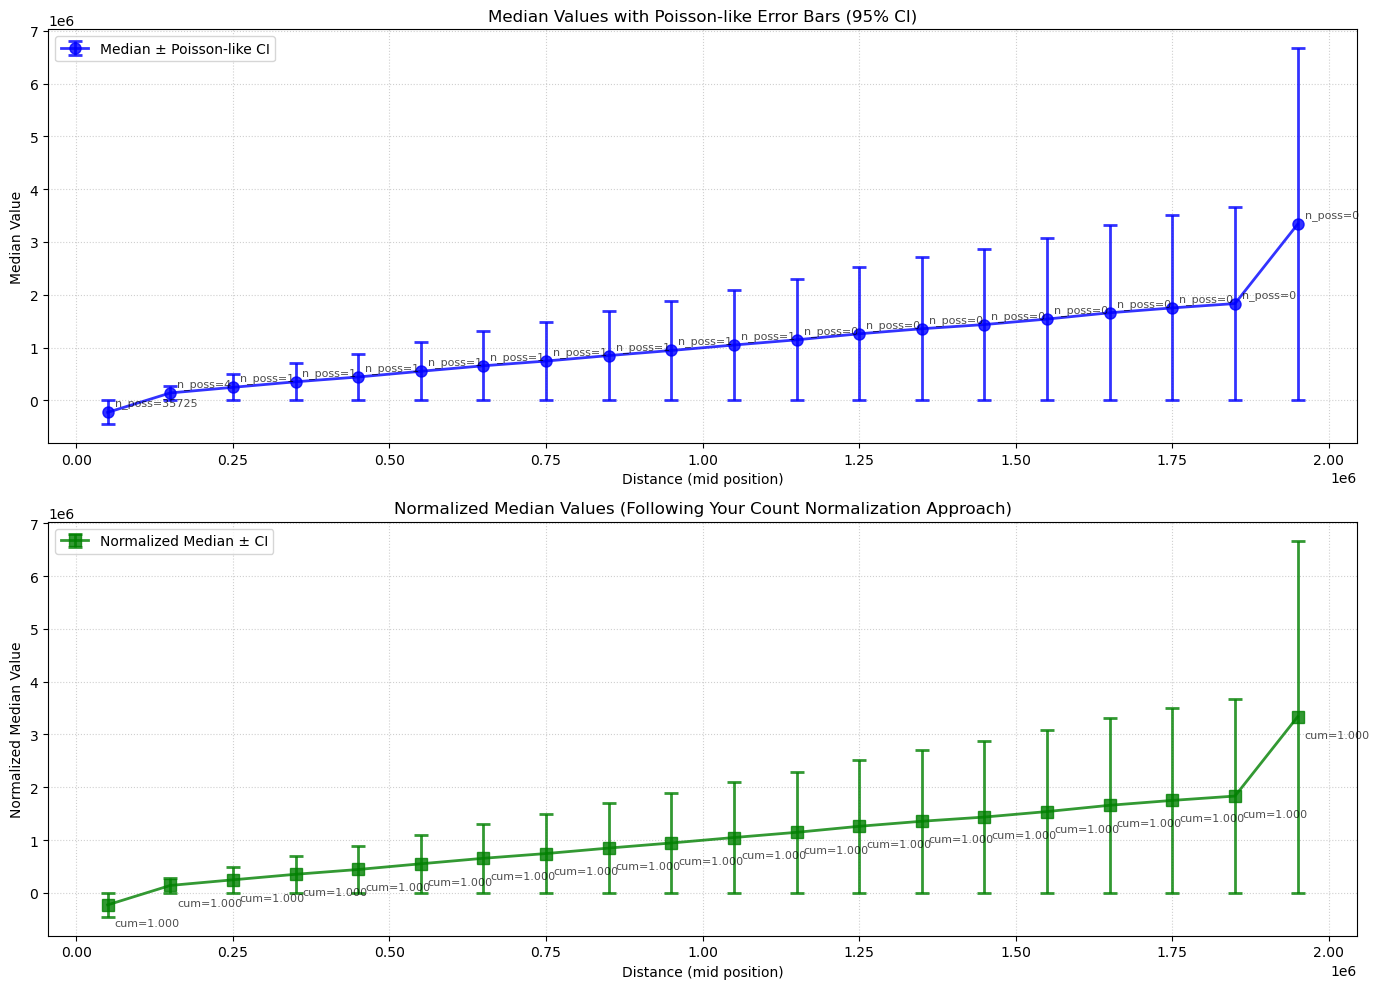

DETAILED BIN STATISTICS (Following Your Approach):
Bin Range                Median     Error      Rev_Cum  Cum_Frac Normalized  
------------------------------------------------------------------------------------------
0   0-100000             -227948.0000 227948.0000 35725    1.000    -227922.4775
1   100000-200000        140472.0000 140472.0000 4        1.000    140468.0680 
2   200000-300000        246617.0000 246617.0000 1        1.000    246610.0968 
3   300000-400000        351632.5000 351632.5000 1        1.000    351622.6572 
4   400000-500000        442533.5000 442533.5000 1        1.000    442521.1128 
5   500000-600000        550718.0000 550718.0000 1        1.000    550702.5845 
6   600000-700000        654832.0000 654832.0000 1        1.000    654813.6702 
7   700000-800000        744558.0000 744558.0000 1        1.000    744537.1586 
8   800000-900000        848309.2500 848309.2500 1        1.000    848285.5045 
9   900000-1000000       944728.0000 944728.0000 1        1

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bin_half_distances_by_compartment(comp, max_dist=2_000_000, bins=20):
    """
    Bin half-distances between consecutive 'start' positions,
    ignoring compartments (A/B) and returning a single result
    with both forward and reverse cumulative fractions.
    """
    bin_edges = np.linspace(0, max_dist, bins + 1)

    start = comp['start'].values
    if len(start) < 2:
        counts = np.zeros(bins, dtype=int)
    else:
        half_distances = [(start[i+1] - start[i]) / 2 for i in range(len(start) - 1)]
        counts, _ = np.histogram(half_distances, bins=bin_edges)

    total = np.sum(counts)
    if total > 0:
        cumulative_fraction = np.cumsum(counts) / total
        reverse_cumulative_fraction = np.cumsum(counts[::-1])[::-1] / total
    else:
        cumulative_fraction = np.zeros(bins, dtype=float)
        reverse_cumulative_fraction = np.zeros(bins, dtype=float)

    reverse_cumulative = np.cumsum(counts[::-1])[::-1]

    result = {
        "counts": counts,
        "cumulative_fraction": cumulative_fraction,
        "reverse_cumulative_fraction": reverse_cumulative_fraction,
        "reverse_cumulative": reverse_cumulative
    }
    return result

def bin_median_with_poisson_errors(values, bins, reverse_cumulative):
    """
    Calculate median values per bin and Poisson-like errors based on reverse cumulative.
    Similar to bin_absmid_with_sd but for median instead of counts.
    
    Returns:
      medians: (num_bins,) median value per bin
      errors: (num_bins,) symmetric 95% CI based on reverse cumulative
    """
    # Get bin assignments for each value
    bin_indices = np.digitize(values, bins) - 1
    bin_indices = np.clip(bin_indices, 0, len(bins) - 2)  # Ensure valid indices
    
    medians = np.full(len(bins) - 1, np.nan)
    counts = np.zeros(len(bins) - 1, dtype=int)
    
    # Calculate median for each bin
    for i in range(len(bins) - 1):
        bin_mask = (bin_indices == i)
        if np.any(bin_mask):
            bin_values = values[bin_mask]
            medians[i] = np.median(bin_values)
            counts[i] = len(bin_values)
    
    # Calculate errors using reverse cumulative (same approach as your count data)
    n_possible = np.maximum(reverse_cumulative.astype(float), 1.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # For median, we use the count of observations and scale by median value
        # This gives us a relative error that scales with the magnitude
        relative_sd = np.sqrt(counts.astype(float) / n_possible)
        relative_sd[np.isnan(relative_sd)] = 0.0
    
    # Scale the relative error by the median value to get absolute error
    # Use 1.96 for 95% CI (same as your original code)
    errors = 1.96 * relative_sd * np.abs(medians)
    errors[np.isnan(medians)] = 0.0
    
    # Ensure error bars don't make values go negative
    # Cap the error at the median value itself (so lower bound = 0)
    errors = np.minimum(errors, np.abs(medians))
    errors[np.isnan(medians)] = 0.0
    
    return medians, errors

# Parameters
max_dist = 2_000_000
bins = 20

# Create bin edges and centers
bin_edges = np.linspace(0, max_dist, bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Get reverse cumulative information using your function
reverse_cum_info = bin_half_distances_by_compartment(result_with_comp_chr8_B, max_dist, bins)

# Calculate median values and Poisson-like errors
mid_values = result_with_comp_chr8_B['mid'].dropna().values
value_array = result_with_comp_chr8_B['value'].dropna().values

# Use the same approach as your count normalization
medians, errors = bin_median_with_poisson_errors(mid_values, bin_edges, reverse_cum_info["reverse_cumulative"])

# Apply normalization factor and ensure no negative values
norm_cum = np.where(reverse_cum_info["cumulative_fraction"] == 0, np.nan, reverse_cum_info["cumulative_fraction"])
normalized_medians = medians * norm_cum
normalized_errors = errors * norm_cum

# Ensure normalized error bars also don't make values go negative
normalized_errors = np.minimum(normalized_errors, np.abs(normalized_medians))
normalized_errors[np.isnan(normalized_medians)] = 0.0

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Raw medians with Poisson errors
valid_mask = ~np.isnan(medians)
ax1.errorbar(bin_centers[valid_mask], medians[valid_mask], 
            yerr=errors[valid_mask], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2,
            label='Median ± Poisson-like CI', color='blue', alpha=0.8)

ax1.set_xlabel('Distance (mid position)')
ax1.set_ylabel('Median Value')
ax1.set_title('Median Values with Poisson-like Error Bars (95% CI)')
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()
ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Add sample info annotations (similar to your original)
for i, (x, y, rev_cum) in enumerate(zip(bin_centers[valid_mask], medians[valid_mask], 
                                       reverse_cum_info["reverse_cumulative"][valid_mask])):
    ax1.annotate(f'n_poss={int(rev_cum)}', (x, y), xytext=(5, 5), 
                textcoords='offset points', fontsize=8, alpha=0.7)

# Plot 2: Normalized medians (like your normalized counts)
norm_valid_mask = ~np.isnan(normalized_medians)
ax2.errorbar(bin_centers[norm_valid_mask], normalized_medians[norm_valid_mask], 
            yerr=normalized_errors[norm_valid_mask], 
            fmt='s-', linewidth=2, markersize=8, capsize=5, capthick=2,
            label='Normalized Median ± CI', color='green', alpha=0.8)

ax2.set_xlabel('Distance (mid position)')
ax2.set_ylabel('Normalized Median Value')
ax2.set_title('Normalized Median Values (Following Your Count Normalization Approach)')
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()
ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Add cumulative fraction info
for i, (x, y, cum_frac) in enumerate(zip(bin_centers[norm_valid_mask], 
                                        normalized_medians[norm_valid_mask], 
                                        reverse_cum_info["cumulative_fraction"][norm_valid_mask])):
    ax2.annotate(f'cum={cum_frac:.3f}', (x, y), xytext=(5, -15), 
                textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Print detailed statistics (similar to your original code format)
print("DETAILED BIN STATISTICS (Following Your Approach):")
print("=" * 90)
print(f"{'Bin':<3} {'Range':<20} {'Median':<10} {'Error':<10} {'Rev_Cum':<8} {'Cum_Frac':<8} {'Normalized':<12}")
print("-" * 90)

for i in range(bins):
    if not np.isnan(medians[i]):
        bin_range = f"{bin_edges[i]:.0f}-{bin_edges[i+1]:.0f}"
        rev_cum = reverse_cum_info["reverse_cumulative"][i]
        cum_frac = reverse_cum_info["cumulative_fraction"][i]
        norm_med = normalized_medians[i] if not np.isnan(normalized_medians[i]) else 0
        
        print(f"{i:<3} {bin_range:<20} {medians[i]:<10.4f} {errors[i]:<10.4f} "
              f"{int(rev_cum):<8} {cum_frac:<8.3f} {norm_med:<12.4f}")

print(f"\nTotal observations: {len(result_with_comp_chr8_B)}")
print(f"Bins with data: {np.sum(~np.isnan(medians))}")
print("\nERROR CALCULATION:")
print("- Uses reverse_cumulative counts as 'n_possible' (like your count approach)")
print("- Error = 1.96 * sqrt(count_in_bin / n_possible) * median_value")
print("- Error bars capped to prevent negative values (min value = 0)")
print("- Normalized by cumulative_fraction (same as your count normalization)")

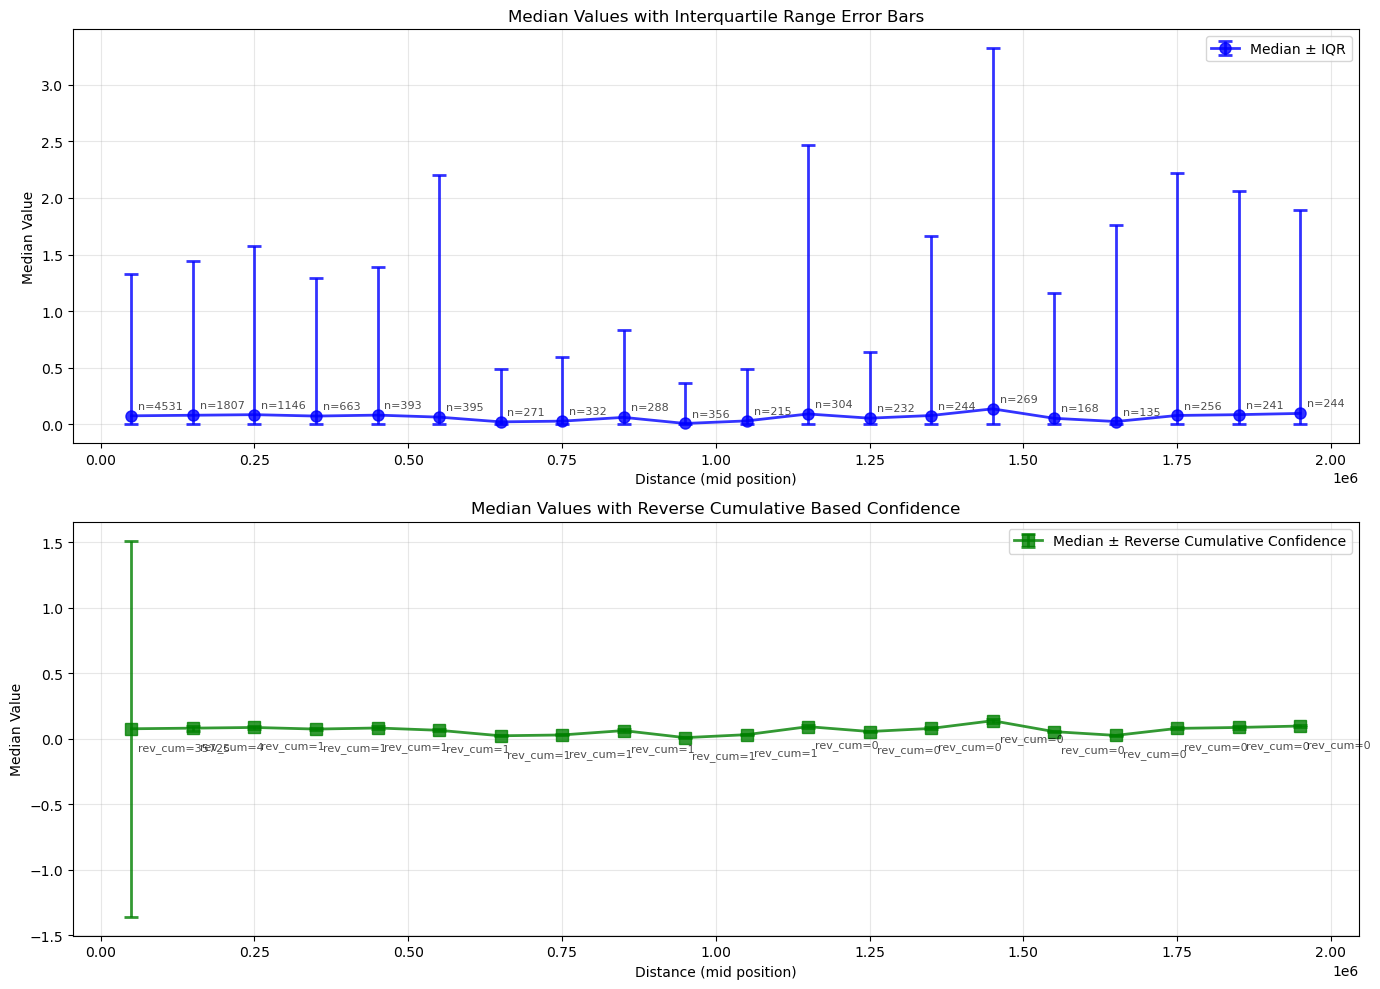

DETAILED BIN STATISTICS:
Bin Range                Count  Median     IQR             Rev_Cum 
--------------------------------------------------------------------------------
0   0-100000             4531   0.0760     1.3277          35725   
1   100000-200000        1807   0.0809     1.4466          4       
2   200000-300000        1146   0.0862     1.5787          1       
3   300000-400000        663    0.0737     1.2948          1       
4   400000-500000        393    0.0821     1.3928          1       
5   500000-600000        395    0.0644     2.2057          1       
6   600000-700000        271    0.0225     0.4853          1       
7   700000-800000        332    0.0289     0.5981          1       
8   800000-900000        288    0.0621     0.8302          1       
9   900000-1000000       356    0.0084     0.3671          1       
10  1000000-1100000      215    0.0310     0.4856          1       
11  1100000-1200000      304    0.0922     2.4691          0       
12  120000

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def bin_half_distances_by_compartment(comp, max_dist=2_000_000, bins=20):
    """
    Bin half-distances between consecutive 'start' positions,
    ignoring compartments (A/B) and returning a single result
    with both forward and reverse cumulative fractions.
    """
    bin_edges = np.linspace(0, max_dist, bins + 1)

    start = comp['start'].values
    if len(start) < 2:
        counts = np.zeros(bins, dtype=int)
    else:
        half_distances = [(start[i+1] - start[i]) / 2 for i in range(len(start) - 1)]
        counts, _ = np.histogram(half_distances, bins=bin_edges)

    total = np.sum(counts)
    if total > 0:
        cumulative_fraction = np.cumsum(counts) / total
        reverse_cumulative_fraction = np.cumsum(counts[::-1])[::-1] / total
    else:
        cumulative_fraction = np.zeros(bins)
        reverse_cumulative_fraction = np.zeros(bins)

    reverse_cumulative = np.cumsum(counts[::-1])[::-1]

    result = {
        "counts": counts,
        "cumulative_fraction": cumulative_fraction,
        "reverse_cumulative_fraction": reverse_cumulative_fraction,
        "reverse_cumulative": reverse_cumulative
    }
    return result

# Parameters
max_dist = 2_000_000
bins = 20

# Create bin edges and centers
bin_edges = np.linspace(0, max_dist, bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Assign each row to a bin based on the 'mid' column
result_with_comp_chr8_B['bin'] = pd.cut(result_with_comp_chr8_B['mid'], 
                                       bins=bin_edges, 
                                       include_lowest=True,
                                       labels=False)

# Calculate median and other statistics for each bin
bin_stats = result_with_comp_chr8_B.groupby('bin')['value'].agg([
    'median', 'mean', 'std', 'count', 'min', 'max',
    lambda x: np.percentile(x, 25),  # Q1
    lambda x: np.percentile(x, 75)   # Q3
])
bin_stats.columns = ['median', 'mean', 'std', 'count', 'min', 'max', 'q1', 'q3']

# Get reverse cumulative information
reverse_cum_info = bin_half_distances_by_compartment(result_with_comp_chr8_B, max_dist, bins)

# Create arrays for plotting
plot_medians = np.full(bins, np.nan)
error_lower = np.full(bins, np.nan)
error_upper = np.full(bins, np.nan)
sample_counts = np.full(bins, np.nan)
reverse_cum_counts = reverse_cum_info['reverse_cumulative']

for bin_idx in bin_stats.index:
    if not np.isnan(bin_idx):
        idx = int(bin_idx)
        stats_row = bin_stats.loc[bin_idx]
        
        plot_medians[idx] = stats_row['median']
        
        # Error bars: Use interquartile range (Q1 to Q3) as a measure of spread
        error_lower[idx] = stats_row['median'] - stats_row['q1']
        error_upper[idx] = stats_row['q3'] - stats_row['median']
        
        sample_counts[idx] = stats_row['count']

# Alternative error calculation using reverse cumulative for confidence
# This represents how many observations could theoretically give this result
confidence_multiplier = np.sqrt(reverse_cum_counts + 1) / 10  # Scale factor for visualization

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Median with IQR error bars
mask = ~np.isnan(plot_medians)
ax1.errorbar(bin_centers[mask], plot_medians[mask], 
            yerr=[error_lower[mask], error_upper[mask]], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2,
            label='Median ± IQR', color='blue', alpha=0.8)

ax1.set_xlabel('Distance (mid position)')
ax1.set_ylabel('Median Value')
ax1.set_title('Median Values with Interquartile Range Error Bars')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Add sample size annotations
for i, (x, y, count) in enumerate(zip(bin_centers[mask], plot_medians[mask], sample_counts[mask])):
    if not np.isnan(count):
        ax1.annotate(f'n={int(count)}', (x, y), xytext=(5, 5), 
                    textcoords='offset points', fontsize=8, alpha=0.7)

# Plot 2: Median with reverse cumulative confidence
# Scale the confidence based on reverse cumulative counts
scaled_confidence = confidence_multiplier[mask] * plot_medians[mask]
ax2.errorbar(bin_centers[mask], plot_medians[mask], 
            yerr=scaled_confidence, 
            fmt='s-', linewidth=2, markersize=8, capsize=5, capthick=2,
            label='Median ± Reverse Cumulative Confidence', color='green', alpha=0.8)

ax2.set_xlabel('Distance (mid position)')
ax2.set_ylabel('Median Value')
ax2.set_title('Median Values with Reverse Cumulative Based Confidence')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

# Add reverse cumulative counts as annotations
for i, (x, y, rev_count) in enumerate(zip(bin_centers[mask], plot_medians[mask], reverse_cum_counts[mask])):
    ax2.annotate(f'rev_cum={int(rev_count)}', (x, y), xytext=(5, -15), 
                textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("DETAILED BIN STATISTICS:")
print("=" * 80)
print(f"{'Bin':<3} {'Range':<20} {'Count':<6} {'Median':<10} {'IQR':<15} {'Rev_Cum':<8}")
print("-" * 80)

for bin_idx in bin_stats.index:
    if not np.isnan(bin_idx):
        idx = int(bin_idx)
        stats_row = bin_stats.loc[bin_idx]
        bin_range = f"{bin_edges[idx]:.0f}-{bin_edges[idx+1]:.0f}"
        iqr = stats_row['q3'] - stats_row['q1']
        rev_cum = reverse_cum_counts[idx]
        
        print(f"{idx:<3} {bin_range:<20} {int(stats_row['count']):<6} "
              f"{stats_row['median']:<10.4f} {iqr:<15.4f} {int(rev_cum):<8}")

print(f"\nTotal observations: {len(result_with_comp_chr8_B)}")
print(f"Bins with data: {len(bin_stats)}")
print("\nERROR BAR EXPLANATIONS:")
print("1. IQR Error Bars: Show the spread of the middle 50% of data in each bin")
print("2. Reverse Cumulative Confidence: Based on how many observations could theoretically give that result")

## hej

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _bin_edges(max_dist=2_000_000, bins=20):
    """Create bin edges and centers for distance binning."""
    edges = np.linspace(0, max_dist, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers

def _comp_sides(df):
    """Split into A-side and B-side using the filtering logic."""
    A_side = df[((df['comp'] == 'A') & (df['mid'] > 0)) |
                ((df['comp'] == 'B') & (df['mid'] < 0))]
    B_side = df[((df['comp'] == 'A') & (df['mid'] < 0)) |
                ((df['comp'] == 'B') & (df['mid'] > 0))]
    return A_side, B_side

def _bin_stats(data_df, edges):
    """Calculate mean and 95% CI using SEM for each bin."""
    means = []
    errs = []
    counts = []
    
    for lo, hi in zip(edges[:-1], edges[1:]):
        # Use absolute value of mid for distance binning
        sel = data_df[(data_df["mid"].abs() >= lo) & (data_df["mid"].abs() < hi)]["value"].dropna().to_numpy()
        n = sel.size
        counts.append(n)
        
        if n == 0:
            means.append(np.nan)
            errs.append(np.nan)
            continue
            
        m = float(sel.mean())
        if n == 1:
            # Single-point: plot point, small default error
            e = 0.05 * abs(m) if abs(m) > 0 else 0.01
        else:
            sd = sel.std(ddof=1)
            sem = sd / np.sqrt(n)
            e = 1.96 * sem  # 95% CI
        
        means.append(m)
        errs.append(e)
    
    return np.array(means), np.array(errs), np.array(counts)

def plot_recombination_by_compartment(ax, df, title, max_dist=2_000_000, bins=20):
    """
    Plot recombination data by compartment similar to the GC plotting style.
    
    Parameters:
    ax: matplotlib axis object
    df: DataFrame with remapped recombination data
    title: Plot title
    max_dist: Maximum distance to include
    bins: Number of bins
    
    Returns:
    ax: Updated axis object
    """
    # Filter by max distance using absolute mid values
    df = df.loc[df["mid"].abs() <= max_dist].copy()
    edges, centers = _bin_edges(max_dist, bins)
    
    # Split into A-side and B-side
    A_side, B_side = _comp_sides(df)
    
    print(f"Plotting {title}:")
    print(f"  Total intervals: {len(df)}")
    print(f"  A-side intervals: {len(A_side)}")
    print(f"  B-side intervals: {len(B_side)}")
    
    # Calculate statistics
    A_m, A_e, A_n = _bin_stats(A_side, edges)
    B_m, B_e, B_n = _bin_stats(B_side, edges)
    
    # Colors matching your original script
    A_color = "#117733"  # deep teal green
    B_color = "#E69F00"  # rich amber/orange
    
    # Plot with error bars
    ax.errorbar(centers, A_m, yerr=A_e, marker='o', linestyle='-',
                label='Compartment A', capsize=3, color=A_color)
    ax.errorbar(centers, B_m, yerr=B_e, marker='s', linestyle='--',
                label='Compartment B', capsize=3, color=B_color)
    
    ax.set_title(title)
    ax.set_xlabel("Distance to compartment edge (bp)")
    ax.set_ylabel("Average recombination rate")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    
    return ax

def plot_single_recombination_analysis(df, title="Recombination Rate Analysis", 
                                     max_dist=2_000_000, bins=20, figsize=(10, 6)):
    """
    Create a single plot for recombination analysis.
    
    Parameters:
    df: Combined DataFrame with both A and B compartment data
    title: Plot title
    max_dist: Maximum distance to plot
    bins: Number of bins
    figsize: Figure size
    
    Returns:
    fig, ax: matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    plot_recombination_by_compartment(ax, df, title, max_dist, bins)
    plt.tight_layout()
    return fig, ax

def plot_multiple_recombination_datasets(datasets, max_dist=2_000_000, bins=20, 
                                       ncols=2, figsize=(15, 12)):
    """
    Plot multiple recombination datasets in subplots.
    
    Parameters:
    datasets: List of (title, dataframe) tuples
    max_dist: Maximum distance to plot
    bins: Number of bins
    ncols: Number of columns in subplot grid
    figsize: Figure size
    
    Returns:
    fig: matplotlib figure object
    """
    n = len(datasets)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    
    for i, (title, df) in enumerate(datasets):
        plot_recombination_by_compartment(axes[i], df, title, max_dist, bins)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    fig.tight_layout()
    return fig

# Simple usage functions
def quick_plot_single(combined_df, title="Recombination Analysis"):
    """
    Quick single plot function.
    Usage: fig, ax = quick_plot_single(pd.concat([result_with_comp_chrx_A, result_with_comp_chrx_B]))
    """
    return plot_single_recombination_analysis(combined_df, title)

def quick_plot_comparison(A_data, B_data, title="Recombination Analysis"):
    """
    Quick plot function for separate A and B dataframes.
    Usage: fig, ax = quick_plot_comparison(result_with_comp_chrx_A, result_with_comp_chrx_B)
    """
    combined_df = pd.concat([A_data, B_data], ignore_index=True)
    return plot_single_recombination_analysis(combined_df, title)

# Usage examples:
# 
# Method 1: Combine your dataframes first
# combined_data = pd.concat([result_with_comp_chrx_A, result_with_comp_chrx_B], ignore_index=True)
# fig, ax = plot_single_recombination_analysis(combined_data, "chrX Recombination Analysis")
# plt.show()
#
# Method 2: Use quick functions
# fig, ax = quick_plot_comparison(result_with_comp_chrx_A, result_with_comp_chrx_B, "chrX Recombination")
# plt.show()
#
# Method 3: Multiple datasets
# datasets = [
#     ("Dataset 1", combined_data1),
#     ("Dataset 2", combined_data2),
#     ("Dataset 3", combined_data3)
# ]
# fig = plot_multiple_recombination_datasets(datasets, bins=25)
# plt.show()

Plotting chrX Recombination Analysis:
  Total intervals: 17372
  A-side intervals: 10154
  B-side intervals: 7218


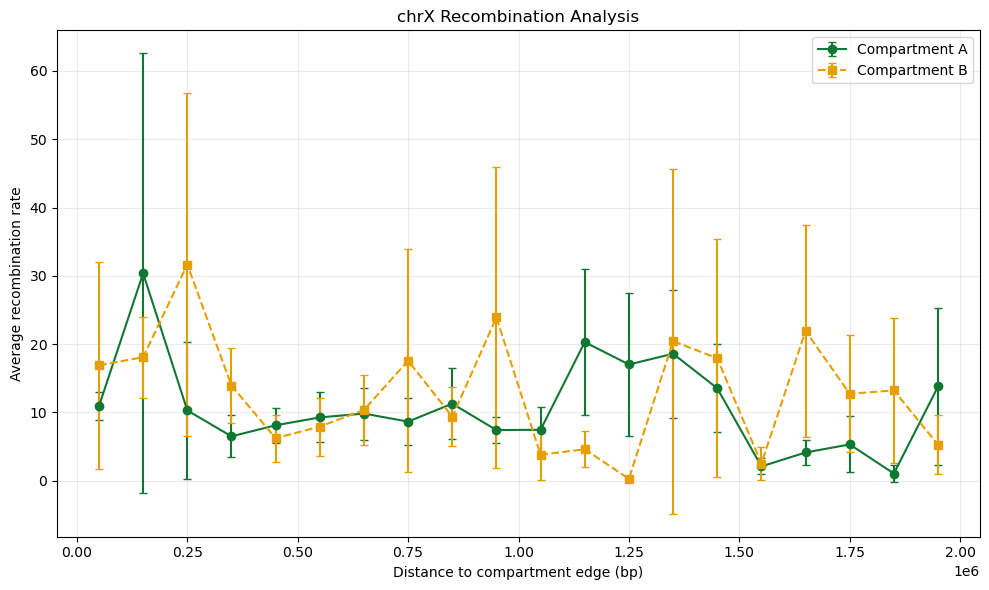

In [ ]:
# Combine your A and B data
combined_data = pd.concat([result_with_comp_chrx_A, result_with_comp_chrx_B], ignore_index=True)

# Plot
fig, ax = plot_single_recombination_analysis(combined_data, "chrX Recombination Analysis")
plt.show()

Plotting chrX Recombination Analysis:
  Total intervals: 45480
  A-side intervals: 19248
  B-side intervals: 26232


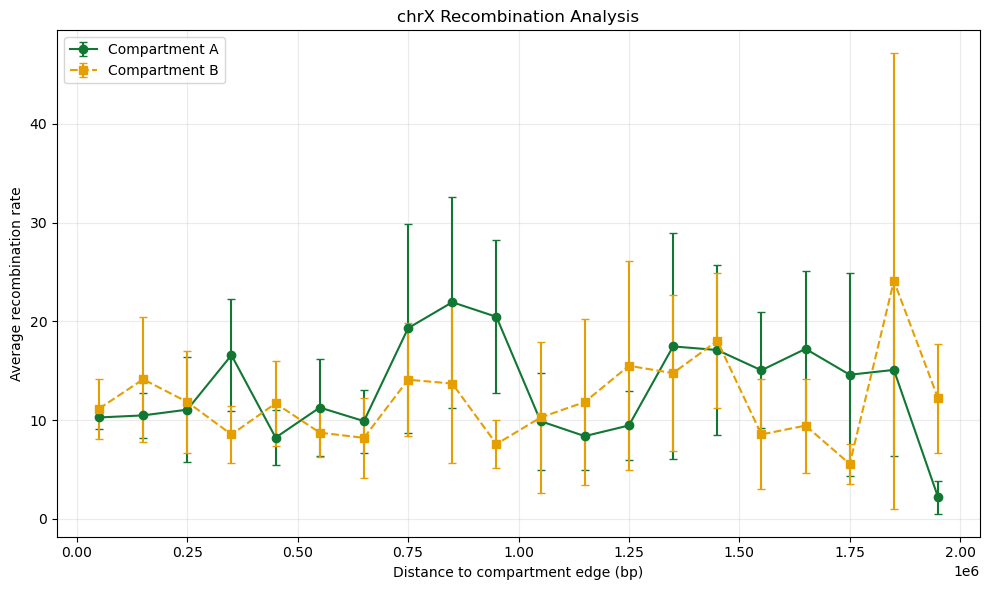

In [ ]:
# Combine your A and B data
combined_data = pd.concat([result_with_comp_chr8_A, result_with_comp_chr8_B], ignore_index=True)

# Plot
fig, ax = plot_single_recombination_analysis(combined_data, "chrX Recombination Analysis")
plt.show()